# Stroke Risk Prediction – Exploratory Data Analysis

Goal: Understand key risk factors and patterns in stroke patients to support early detection and healthcare decision-making.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

sns.set(style="whitegrid")

# Load and Inspect Data
## Dataset

The dataset contains demographic and clinical information such as:

* Age
* Hypertension
* Heart disease
* Smoking status
* Glucose levels
* Body mass index (BMI)

The target variable indicates whether the patient experienced a stroke.


In [2]:
df = pd.read_csv("../data/stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


## Data Cleaning and Preprocessing
Handling missing BMI values and preparing categorical variables.

Missing BMI values were imputed using the median. Categorical variables were encoded, and class imbalance was addressed using SMOTE.


In [4]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [5]:
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# Splitting the features and target

In [6]:
X = df.drop("stroke", axis=1)
y = df["stroke"]

# Identify categorical columns

In [7]:
categorical_cols = X.select_dtypes(include="object").columns

C:\Users\DELL\AppData\Local\Temp\ipykernel_4352\3963226579.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns


# One-hot encode

In [8]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Train - test split

In [11]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y )

# SMOTE

In [12]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: stroke
0    3889
1     199
Name: count, dtype: int64
After SMOTE: stroke
0    3889
1    3889
Name: count, dtype: int64


## Exploratory Analysis
Understanding key risk factors such as age, hypertension, heart disease, and smoking.

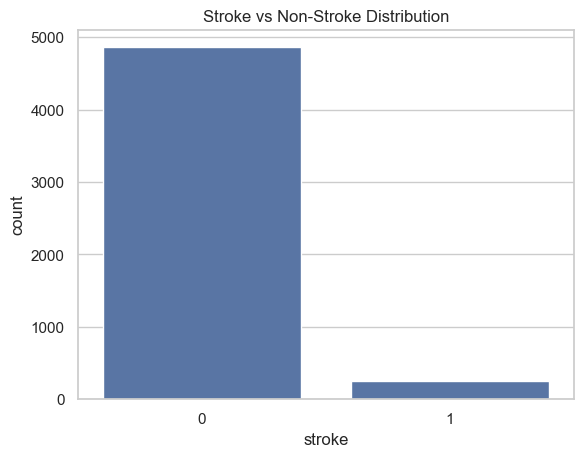

In [13]:
sns.countplot(x='stroke', data=df)
plt.title("Stroke vs Non-Stroke Distribution")
plt.show()

The dataset is highly imbalanced. This motivates the use of SMOTE and threshold tuning later.

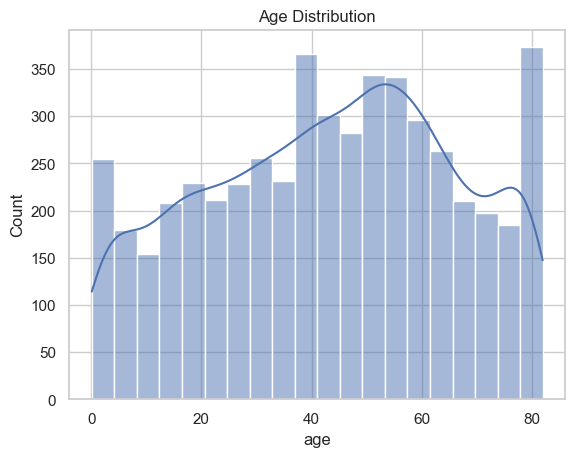

In [15]:
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

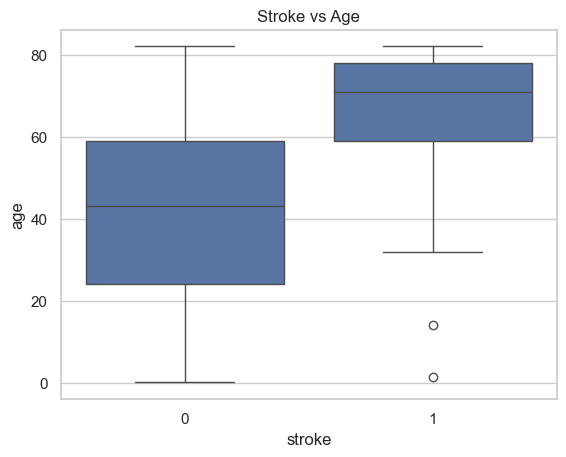

In [16]:
sns.boxplot(x='stroke', y='age', data=df)
plt.title("Stroke vs Age")
plt.show()

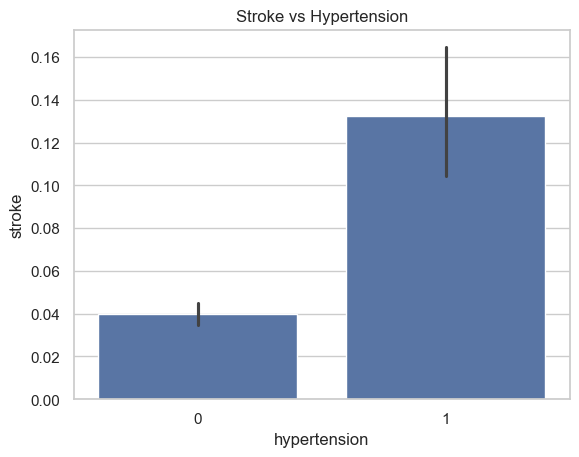

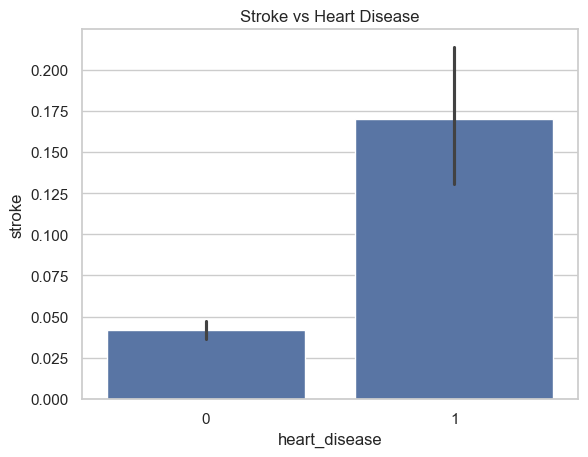

In [17]:
sns.barplot(x='hypertension', y='stroke', data=df)
plt.title("Stroke vs Hypertension")
plt.show()

sns.barplot(x='heart_disease', y='stroke', data=df)
plt.title("Stroke vs Heart Disease")
plt.show()

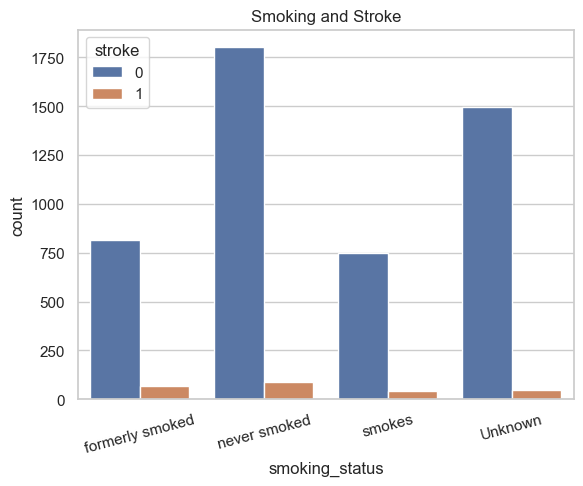

In [18]:
sns.countplot(x='smoking_status', hue='stroke', data=df)
plt.xticks(rotation=15)
plt.title("Smoking and Stroke")
plt.show()

Key observations:

• Age, hypertension, and heart disease show strong association with stroke.
• The dataset is imbalanced, requiring resampling and threshold tuning.
• Lifestyle and glucose patterns suggest opportunities for predictive modeling.

These findings guide feature engineering and model selection.

In [19]:
# Save cleaned dataset
df.to_csv("../data/stroke_cleaned.csv", index=False)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!
